In [1]:
from spockflow.components.tree import Tree, Action, TableCondition
from spockflow.core import initialize_spock_module
import pandas as pd

from spockflow.components import dtable

from typing_extensions import TypedDict


class Reject(TypedDict):
    code: int
    description: str


RejectAction = Action[Reject]


tree = Tree()


@tree.condition(output=pd.DataFrame([dict(code=102, description="My first condition")]))
def first_condition(d: pd.Series, e: pd.Series, f: pd.Series) -> pd.Series:
    return (d > 5) & (e > 5) & (f > 5)

/Users/cp371651/.pyenv/versions/spock/lib/python3.12/site-packages/pyspark/pandas/__init__.py:50: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


In [2]:
tree = Tree()


@tree.condition(output=RejectAction(code=102, description="My first condition"))
def first_condition(d: pd.Series, e: pd.Series, f: pd.Series) -> pd.Series:
    return (d > 5) & (e > 5) & (f > 5)

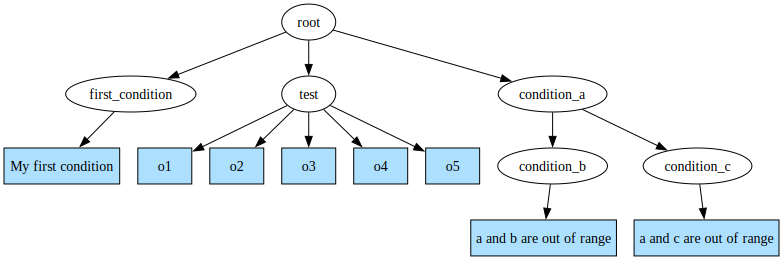

In [3]:
example_dt = (
    dtable.DecisionTable()
    .add(dtable.DTMin, "input_v1", [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    .add(dtable.DTMax, "input_v1", [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])
    .add(dtable.DTMin, "input_v2", [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
    .add(dtable.DTMax, "input_v2", [1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2])
    .set_default(pd.DataFrame({"value": [1]}))
    .output("value", [0, 2, 4, 0, 2, 3, 2, 2, 1, 1])
)

tree = Tree()


@tree.condition(output=RejectAction(code=102, description="My first condition"))
def first_condition(d: pd.Series, e: pd.Series, f: pd.Series) -> pd.Series:
    return (d > 5) & (e > 5) & (f > 5)


tree.condition(
    condition=TableCondition(name="test", table=example_dt),
    output=[
        RejectAction(code=100, description="o1"),
        RejectAction(code=100, description="o2"),
        RejectAction(code=100, description="o3"),
        RejectAction(code=100, description="o4"),
        RejectAction(code=100, description="o5"),
    ],
)


@tree.condition()
def condition_a(a: pd.Series) -> pd.Series:
    return a > 5


@condition_a.condition(
    output=RejectAction(code=100, description="a and b are out of range")
)
def condition_b(b: pd.Series) -> pd.Series:
    return b > 5


@condition_a.condition(
    output=RejectAction(code=101, description="a and c are out of range")
)
def condition_c(c: pd.Series) -> pd.Series:
    return c > 5


tree.visualize(get_value_name=lambda x: x["description"][0])

In [4]:
%load_ext hamilton.plugins.jupyter_magic

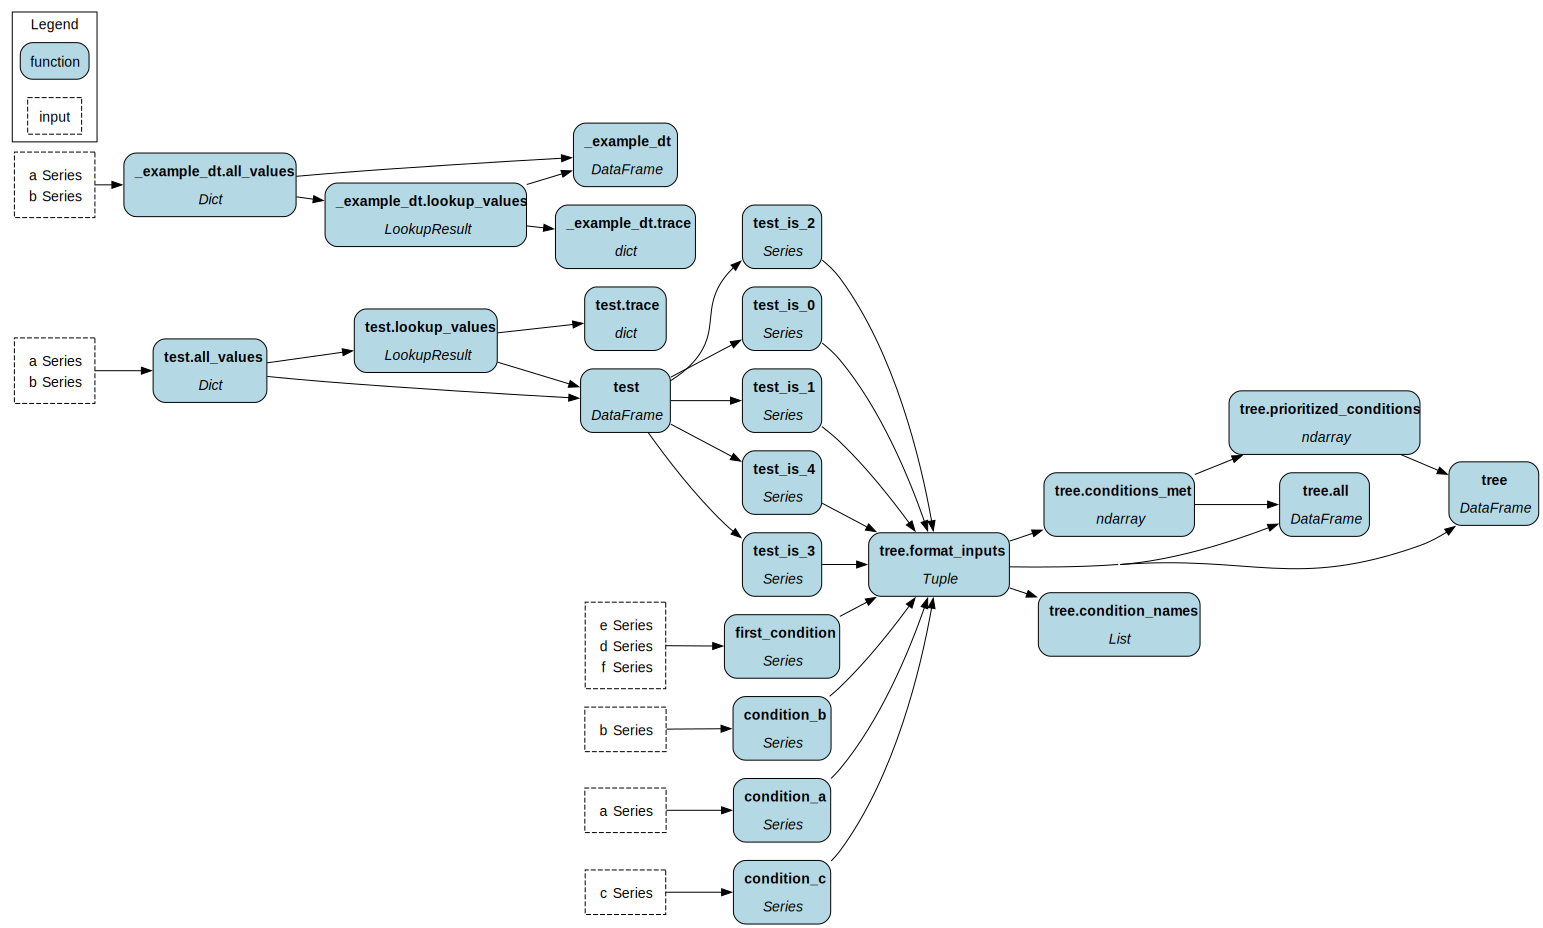

In [5]:
%%cell_to_module --display -m demo_tree

# Import necessary packages
from typing import TypedDict
import pandas as pd

from spockflow.components.tree import Tree, Action, TableCondition
from spockflow.core import initialize_spock_module
import pandas as pd

from spockflow.components import dtable

from typing_extensions import TypedDict

class Reject(TypedDict):
    code: int
    description: str

RejectAction = Action[Reject]


_example_dt = dtable.DecisionTable()\
    .add(dtable.DTMin,   "a", [0,1,2,3,4,5,6,7,8,9,10])\
    .add(dtable.DTMax,   "a", [1,2,3,4,5,6,7,8,9,10,11])\
    .add(dtable.DTMin,   "b", [0,0,0,0,0,0,1,1,1,1,1])\
    .add(dtable.DTMax,   "b", [1,1,1,1,1,1,2,2,2,2,2])\
    .set_default(pd.DataFrame({"value": [1]}))\
    .output("value", [0,2,4,0,2,3,2,2,1,1])

tree = Tree()
@tree.condition(output=RejectAction(code=102, description="My first condition"))
def first_condition(d: pd.Series, e: pd.Series, f: pd.Series) -> pd.Series:
    return (d > 5) & (e > 5) & (f > 5)

tree.condition(condition=TableCondition(name="test", table = _example_dt), output=[
    RejectAction(code=100, description="o1"),
    RejectAction(code=100, description="o2"),
    RejectAction(code=100, description="o3"),
    RejectAction(code=100, description="o4"),
    RejectAction(code=100, description="o5"),
])

@tree.condition()
def condition_a(a: pd.Series) -> pd.Series:
    return a > 5

@condition_a.condition(output=RejectAction(code=100, description="a and b are out of range"))
def condition_b(b: pd.Series) -> pd.Series:
    return b > 5

@condition_a.condition(output=RejectAction(code=101, description="a and c are out of range"))
def condition_c(c: pd.Series) -> pd.Series:
    return c > 5
tree.visualize(get_value_name=lambda x: x["description"][0])
initialize_spock_module(__name__, output_names=["tree"])

In [6]:
test_data = pd.DataFrame(
    {
        "a": [5, 6, 7, 8, 1, 2, 3, 4],
        "b": [1, 0, 0, 0, 2, 0, 0, 0],
        "c": [0, 10, 0, 0, 0, 10, 0, 0],
        "d": [0, 0, 10, 0, 0, 0, 0, 0],
        "e": [0, 0, 10, 0, 0, 0, 0, 0],
        "f": [0, 0, 10, 0, 0, 0, 0, 0],
        # Below used later in the tutorial
        "nums": [1, 2, 3, 4, 5, 6, 7, 8],
        "input_condition": [True, True, False, False, False, False, True, True],
    }
)
test_data

,a,b,c,d,e,f,nums,input_condition
0,5,1,0,0,0,0,1,True
1,6,0,10,0,0,0,2,True
2,7,0,0,10,10,10,3,False
3,8,0,0,0,0,0,4,False
4,1,2,0,0,0,0,5,False
5,2,0,10,0,0,0,6,False
6,3,0,0,0,0,0,7,True
7,4,0,0,0,0,0,8,True


In [7]:
from spockflow.core import Driver

# Initialize Driver with the decision tree module
dr = Driver({}, demo_tree)

# Execute the DAG with test data
df = dr.execute(inputs=test_data, final_vars=["tree"])
print(df)

  code         description
0  100                  o2
1  100                  o2
2  102  My first condition
3  100                  o2
4  100                  o2
5  100                  o5
6  100                  o1
7  100                  o3


In [8]:
tree_json = tree.model_dump_json(indent=2)

In [9]:
print(tree_json)

{
  "doc": "This executes a user defined decision tree",
  "root": {
    "nodes": [
      {
        "condition_type": "base",
        "value": {
          "type": "DataFrame",
          "values": {
            "code": 102,
            "description": "My first condition"
          },
          "dtypes": {
            "code": "int64",
            "description": "object"
          }
        },
        "condition": "first_condition",
        "priority": null
      },
      {
        "condition_type": "table",
        "values": [
          {
            "type": "DataFrame",
            "values": {
              "code": 100,
              "description": "o1"
            },
            "dtypes": {
              "code": "int64",
              "description": "object"
            }
          },
          {
            "type": "DataFrame",
            "values": {
              "code": 100,
              "description": "o2"
            },
            "dtypes": {
              "code": "int64",
    

In [10]:
tree_dict = tree.model_dump_json(indent=2)
print(tree_dict)

{
  "doc": "This executes a user defined decision tree",
  "root": {
    "nodes": [
      {
        "condition_type": "base",
        "value": {
          "type": "DataFrame",
          "values": {
            "code": 102,
            "description": "My first condition"
          },
          "dtypes": {
            "code": "int64",
            "description": "object"
          }
        },
        "condition": "first_condition",
        "priority": null
      },
      {
        "condition_type": "table",
        "values": [
          {
            "type": "DataFrame",
            "values": {
              "code": 100,
              "description": "o1"
            },
            "dtypes": {
              "code": "int64",
              "description": "object"
            }
          },
          {
            "type": "DataFrame",
            "values": {
              "code": 100,
              "description": "o2"
            },
            "dtypes": {
              "code": "int64",
    

In [11]:
tree_dict = tree.model_dump(mode="json")
tree_dict

{'doc': 'This executes a user defined decision tree',
 'root': {'nodes': [{'condition_type': 'base',
    'value': {'type': 'DataFrame',
     'values': {'code': 102, 'description': 'My first condition'},
     'dtypes': {'code': 'int64', 'description': 'object'}},
    'condition': 'first_condition',
    'priority': None},
   {'condition_type': 'table',
    'values': [{'type': 'DataFrame',
      'values': {'code': 100, 'description': 'o1'},
      'dtypes': {'code': 'int64', 'description': 'object'}},
     {'type': 'DataFrame',
      'values': {'code': 100, 'description': 'o2'},
      'dtypes': {'code': 'int64', 'description': 'object'}},
     {'type': 'DataFrame',
      'values': {'code': 100, 'description': 'o3'},
      'dtypes': {'code': 'int64', 'description': 'object'}},
     {'type': 'DataFrame',
      'values': {'code': 100, 'description': 'o4'},
      'dtypes': {'code': 'int64', 'description': 'object'}},
     {'type': 'DataFrame',
      'values': {'code': 100, 'description': 'o5'}

In [7]:
Tree.model_validate_json(tree_json)

Tree(doc='This executes a user defined decision tree', root=ChildTree(nodes=[ConditionedNode(condition_type='base', value=ChildTree(nodes=[], default_value=None), condition='first_condition', priority=None), TableConditionedNode(condition_type='table', values=[ChildTree(nodes=[], default_value=None), ChildTree(nodes=[], default_value=None), ChildTree(nodes=[], default_value=None), ChildTree(nodes=[], default_value=None), ChildTree(nodes=[], default_value=None)], condition_table='test', priority=None), ConditionedNode(condition_type='base', value=ChildTree(nodes=[ConditionedNode(condition_type='base', value=ChildTree(nodes=[], default_value=None), condition='condition_b', priority=None), ConditionedNode(condition_type='base', value=ChildTree(nodes=[], default_value=None), condition='condition_c', priority=None)], default_value=None), condition='condition_a', priority=None)], default_value=None), decision_tables={'test': DecisionTable(operations=[DTMin(predicate=[0, 1, 2, 3, 4, 5, 6, 7, 

In [11]:
dtable.DecisionTable.model_validate(tree_dict["decision_tables"]["test"])

DecisionTable(operations=[DTMin(predicate=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], op='MIN'), DTMax(predicate=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], op='MAX'), DTMin(predicate=[0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1], op='MIN'), DTMax(predicate=[1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2], op='MAX')], operation_inputs=['input_v1', 'input_v1', 'input_v2', 'input_v2'], outputs={'value': [0, 2, 4, 0, 2, 3, 2, 2, 1, 1]}, allow_multi_result=False, default_value=   value description
0      1          NA)

In [10]:
import typing
import pandas as pd
from pydantic import BaseModel, field_serializer

from spockflow._serializable import DataFrame


class Test(BaseModel):
    value: DataFrame
    # value: typing.Union[typing.Callable[..., pd.DataFrame], DataFrame, str, "Test", None] = None


Test(value=pd.DataFrame({"a": [1]}))

ValidationError: 2 validation errors for Test
value.is-instance[Series]
  Input should be an instance of Series [type=is_instance_of, input_value=   a
0  1, input_type=DataFrame]
    For further information visit https://errors.pydantic.dev/2.6/v/is_instance_of
value.chain[dict[any,any],function-plain[validate_from_dict()]]
  Input should be a valid dictionary [type=dict_type, input_value=   a
0  1, input_type=DataFrame]
    For further information visit https://errors.pydantic.dev/2.6/v/dict_type

In [1]:
import pandas as pd
from typing import Any, Union, Dict

from pydantic_core import core_schema
from typing_extensions import Annotated

from pydantic import (
    BaseModel,
    GetCoreSchemaHandler,
    GetJsonSchemaHandler,
    ValidationError,
)
from pydantic.json_schema import JsonSchemaValue


def dump_dataframe_to_dict(instance: pd.DataFrame) -> Dict[str, Any]:
    """Serialize a DataFrame to a dictionary."""
    return {
        "type": "DataFrame",
        "values": instance.to_dict(orient="list"),
        "columns": list(instance.columns),
        "index": instance.index.tolist(),
    }


def dump_series_to_dict(instance: pd.Series) -> Dict[str, Any]:
    """Serialize a Series to a dictionary."""
    return {
        "type": "Series",
        "values": instance.tolist(),
        "name": instance.name,
        "index": instance.index.tolist(),
    }


class _DataFramePydanticAnnotation:
    @classmethod
    def __get_pydantic_core_schema__(
        cls,
        _source_type: Any,
        _handler: GetCoreSchemaHandler,
    ) -> core_schema.CoreSchema:
        def validate_dataframe(value: dict) -> pd.DataFrame:
            # Ensure the input is a dictionary with the correct type
            if not isinstance(value, dict) or value.get("type") != "DataFrame":
                raise ValueError("Invalid DataFrame representation")

            # Reconstruct DataFrame with original columns and index
            df = pd.DataFrame(
                value["values"], columns=value.get("columns"), index=value.get("index")
            )
            return df

        return core_schema.json_or_python_schema(
            json_schema=core_schema.no_info_plain_validator_function(
                validate_dataframe
            ),
            python_schema=core_schema.union_schema(
                [
                    # Specifically check for DataFrame type
                    core_schema.is_instance_schema(pd.DataFrame),
                    core_schema.no_info_plain_validator_function(validate_dataframe),
                ]
            ),
            serialization=core_schema.plain_serializer_function_ser_schema(
                dump_dataframe_to_dict
            ),
        )

    @classmethod
    def __get_pydantic_json_schema__(
        cls, _core_schema: core_schema.CoreSchema, handler: GetJsonSchemaHandler
    ) -> JsonSchemaValue:
        # Define a more specific JSON schema for DataFrame
        return {
            "type": "object",
            "properties": {
                "type": {"const": "DataFrame"},
                "values": {"type": "object"},
                "columns": {"type": "array"},
                "index": {"type": "array"},
            },
            "required": ["type", "values"],
        }


class _SeriesPydanticAnnotation:
    @classmethod
    def __get_pydantic_core_schema__(
        cls,
        _source_type: Any,
        _handler: GetCoreSchemaHandler,
    ) -> core_schema.CoreSchema:
        def validate_series(value: dict) -> pd.Series:
            # Ensure the input is a dictionary with the correct type
            if not isinstance(value, dict) or value.get("type") != "Series":
                raise ValueError("Invalid Series representation")

            # Reconstruct Series with original name and index
            return pd.Series(
                value["values"], name=value.get("name"), index=value.get("index")
            )

        return core_schema.json_or_python_schema(
            json_schema=core_schema.no_info_plain_validator_function(validate_series),
            python_schema=core_schema.union_schema(
                [
                    # Specifically check for Series type
                    core_schema.is_instance_schema(pd.Series),
                    core_schema.no_info_plain_validator_function(validate_series),
                ]
            ),
            serialization=core_schema.plain_serializer_function_ser_schema(
                dump_series_to_dict
            ),
        )

    @classmethod
    def __get_pydantic_json_schema__(
        cls, _core_schema: core_schema.CoreSchema, handler: GetJsonSchemaHandler
    ) -> JsonSchemaValue:
        # Define a more specific JSON schema for Series
        return {
            "type": "object",
            "properties": {
                "type": {"const": "Series"},
                "values": {"type": "array"},
                "name": {"type": ["string", "null"]},
                "index": {"type": "array"},
            },
            "required": ["type", "values"],
        }


# Type annotations for easy use
DataFrame = Annotated[pd.DataFrame, _DataFramePydanticAnnotation]
Series = Annotated[pd.Series, _SeriesPydanticAnnotation]


# Example usage
class MyModel(BaseModel):
    data: DataFrame
    metric: Series


# Create sample DataFrame and Series
df = pd.DataFrame({"A": [1, 2, 3], "B": [4, 5, 6]})
series = pd.Series([10, 20, 30], name="values")

# Create a model instance
model = MyModel(data=df, metric=series)

# Serialize to dictionary
serialized = model.model_dump()
print("Serialized:", serialized)

# Deserialize back to model
reconstructed_model = MyModel.model_validate(serialized)

# Verify reconstruction
print("\nReconstructed DataFrame:")
print(reconstructed_model.data)
print("\nReconstructed Series:")
print(reconstructed_model.metric)

# Demonstrate type-specific validation
try:
    # This should raise a validation error
    invalid_model = MyModel(
        data={"type": "Series", "values": [1, 2, 3]}, metric=series  # Wrong type
    )
except ValidationError as e:
    print("\nValidation Error:", e)

Serialized: {'data': {'type': 'DataFrame', 'values': {'A': [1, 2, 3], 'B': [4, 5, 6]}, 'columns': ['A', 'B'], 'index': [0, 1, 2]}, 'metric': {'type': 'Series', 'values': [10, 20, 30], 'name': 'values', 'index': [0, 1, 2]}}

Reconstructed DataFrame:
   A  B
0  1  4
1  2  5
2  3  6

Reconstructed Series:
0    10
1    20
2    30
Name: values, dtype: int64

Validation Error: 2 validation errors for MyModel
data.is-instance[DataFrame]
  Input should be an instance of DataFrame [type=is_instance_of, input_value={'type': 'Series', 'values': [1, 2, 3]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.6/v/is_instance_of
data.function-plain[validate_dataframe()]
  Value error, Invalid DataFrame representation [type=value_error, input_value={'type': 'Series', 'values': [1, 2, 3]}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.6/v/value_error


In [3]:
def validate_from_dict(value: dict) -> pd.Series:
    data_type = value.get("type")
    if data_type is None:
        return pd.DataFrame(value)
    if value.get("type") == "DataFrame":
        return pd.DataFrame(value["values"])
    return pd.Series(value["values"], name=value["name"])


core_schema.chain_schema(
    [
        core_schema.dict_schema(),  # TODO make this more comprehensive
        core_schema.no_info_plain_validator_function(validate_from_dict),
    ]
)

{'type': 'chain',
 'steps': [{'type': 'dict'},
  {'type': 'function-plain',
   'function': {'type': 'no-info',
    'function': <function __main__.validate_from_dict(value: dict) -> pandas.core.series.Series>}}]}

In [4]:
from dataclasses import dataclass
import typing


@dataclass
class TestClass:
    class_value: int
    class_type: typing.Literal["asdf"]

In [2]:
import pandas as pd
from typing import Any, Union

from pydantic_core import core_schema
from typing_extensions import Annotated

from pydantic import (
    BaseModel,
    GetCoreSchemaHandler,
    GetJsonSchemaHandler,
    ValidationError,
)
from pydantic.json_schema import JsonSchemaValue

In [15]:
values_schema = core_schema.dict_schema(keys_schema=core_schema.str_schema())

dataframe_json_schema = core_schema.model_fields_schema(
    {
        "type": core_schema.model_field(core_schema.literal_schema(["DataFrame"])),
        "values": core_schema.model_field(
            core_schema.union_schema(
                [values_schema, core_schema.list_schema(values_schema)]
            )
        ),
        "dtypes": core_schema.model_field(
            core_schema.with_default_schema(
                core_schema.union_schema(
                    [
                        core_schema.none_schema(),
                        core_schema.dict_schema(
                            keys_schema=core_schema.str_schema(),
                            values_schema=core_schema.str_schema(),
                        ),
                    ]
                ),
                default=None,
            )
        ),
    }
)
series_json_schema = core_schema.model_fields_schema(
    {
        "type": core_schema.model_field(core_schema.literal_schema(["Series"])),
        "values": core_schema.model_field(core_schema.list_schema()),
        "name": core_schema.model_field(
            core_schema.with_default_schema(
                core_schema.union_schema(
                    [core_schema.none_schema(), core_schema.str_schema()]
                ),
                default=None,
            )
        ),
    }
)


def validate_to_dataframe_schema(value: dict) -> pd.DataFrame:
    value, *_ = value
    values = value["values"]
    if isinstance(values, dict):
        values = [values]
    df = pd.DataFrame(values)
    dtypes = value.get("dtypes")
    if dtypes:
        return df.astype(dtypes)
    return df


def validate_to_series_schema(value: dict) -> pd.Series:
    value, *_ = value
    return pd.Series(value["values"], name=value.get("name"))


from_df_dict_schema = core_schema.chain_schema(
    [
        dataframe_json_schema,
        # core_schema.dict_schema(),
        core_schema.no_info_plain_validator_function(validate_to_dataframe_schema),
    ]
)
from_series_dict_schema = core_schema.chain_schema(
    [
        series_json_schema,
        # core_schema.dict_schema(),
        core_schema.no_info_plain_validator_function(validate_to_series_schema),
    ]
)


def dump_df_to_dict(instance: pd.DataFrame) -> dict:
    values = instance.to_dict(orient="records")
    if len(values) == 1:
        values = values[0]
    return {
        "type": "DataFrame",
        "values": values,
        "dtypes": {k: str(v) for k, v in instance.dtypes.items()},
    }


def dump_series_to_dict(instance: pd.Series) -> dict:
    return {"type": "Series", "values": instance.to_list(), "name": instance.name}


class _PandasDataFramePydanticAnnotation:
    @classmethod
    def __get_pydantic_core_schema__(
        cls,
        _source_type: Any,
        _handler: GetCoreSchemaHandler,
    ) -> core_schema.CoreSchema:

        return core_schema.json_or_python_schema(
            json_schema=from_df_dict_schema,
            python_schema=core_schema.union_schema(
                [
                    # check if it's an instance first before doing any further work
                    core_schema.is_instance_schema(pd.DataFrame),
                    from_df_dict_schema,
                ]
            ),
            serialization=core_schema.plain_serializer_function_ser_schema(
                dump_df_to_dict
            ),
        )

    @classmethod
    def __get_pydantic_json_schema__(
        cls, _core_schema: core_schema.CoreSchema, handler: GetJsonSchemaHandler
    ) -> JsonSchemaValue:
        return handler(dataframe_json_schema)


class _PandasSeriesPydanticAnnotation:
    @classmethod
    def __get_pydantic_core_schema__(
        cls,
        _source_type: Any,
        _handler: GetCoreSchemaHandler,
    ) -> core_schema.CoreSchema:

        return core_schema.json_or_python_schema(
            json_schema=from_series_dict_schema,
            python_schema=core_schema.union_schema(
                [
                    # check if it's an instance first before doing any further work
                    core_schema.is_instance_schema(pd.Series),
                    from_series_dict_schema,
                ]
            ),
            serialization=core_schema.plain_serializer_function_ser_schema(
                dump_series_to_dict
            ),
        )

    @classmethod
    def __get_pydantic_json_schema__(
        cls, _core_schema: core_schema.CoreSchema, handler: GetJsonSchemaHandler
    ) -> JsonSchemaValue:
        return handler(dataframe_json_schema)


DataFrame = Annotated[pd.DataFrame, _PandasDataFramePydanticAnnotation]
Series = Annotated[pd.Series, _PandasSeriesPydanticAnnotation]


import typing


class MyModel(BaseModel):
    data: DataFrame
    metric: typing.Union[Series, DataFrame]

In [16]:
df = pd.DataFrame({"A": [1, 2, 3], "B": [4, 5, 6]})
series = pd.Series([10, 20, 30], name="values")

# Create a model instance
model = MyModel(data=df, metric=series)

In [17]:
serialized = model.model_dump()
print("Serialized:", serialized)
reconstructed_model = MyModel.model_validate(serialized)
reconstructed_model

Serialized: {'data': {'type': 'DataFrame', 'values': [{'A': 1, 'B': 4}, {'A': 2, 'B': 5}, {'A': 3, 'B': 6}], 'dtypes': {'A': 'int64', 'B': 'int64'}}, 'metric': {'type': 'Series', 'values': [10, 20, 30], 'name': 'values'}}


MyModel(data=   A  B
0  1  4
1  2  5
2  3  6, metric=0    10
1    20
2    30
Name: values, dtype: int64)

In [6]:
{
    "data": {
        "type": "DataFrame",
        "values": [{"A": 1, "B": 4}, {"A": 2, "B": 5}, {"A": 3, "B": 6}],
        "dtypes": {"A": "int64", "B": "int64"},
    }
}

df = pd.DataFrame({"A": [1, 2, 3], "B": [4, 5, 6]})

model = MyModel2(data=df)

serialized = model.model_dump()
print("Serialized:", serialized)

reconstructed_model = MyModel2.model_validate(serialized)
reconstructed_model

NameError: name 'MyModel2' is not defined

In [16]:
serialized.pop()

{'data': {'type': 'DataFrame',
  'values': {'A': [1, 2, 3], 'B': [4, 5, 6]},
  'columns': ['A', 'B'],
  'index': [0, 1, 2]}}

In [2]:
import pandas as pd
from typing import Any, Union

from pydantic_core import core_schema
from typing_extensions import Annotated

from pydantic import (
    BaseModel,
    GetCoreSchemaHandler,
    GetJsonSchemaHandler,
)
from pydantic.json_schema import JsonSchemaValue


def validate_to_dataframe_schema(value: dict) -> pd.DataFrame:
    # Ensure the input is a dictionary with the correct type
    if not isinstance(value, dict) or value.get("type") != "DataFrame":
        raise ValueError("Invalid DataFrame representation")

    values = value["values"]
    # Handle both single dict and list of dicts
    if isinstance(values, dict):
        values = [values]

    # Reconstruct DataFrame with specified dtypes
    dtypes = value.get("dtypes", {})
    return pd.DataFrame(values, dtype=dtypes)


def dump_df_to_dict(instance: pd.DataFrame) -> dict:
    # Convert DataFrame to dictionary representation
    values = instance.to_dict(orient="list")

    # Simplify values if there's only one column
    if len(values) == 1:
        values = values[list(values.keys())[0]]

    return {
        "type": "DataFrame",
        "values": values,
        "dtypes": {k: str(v) for k, v in instance.dtypes.items()},
    }


class _PandasDataFramePydanticAnnotation:
    @classmethod
    def __get_pydantic_core_schema__(
        cls,
        _source_type: Any,
        _handler: GetCoreSchemaHandler,
    ) -> core_schema.CoreSchema:
        # Create schemas for different parts of the DataFrame representation
        values_schema = core_schema.dict_schema(keys_schema=core_schema.str_schema())

        dataframe_json_schema = core_schema.model_fields_schema(
            {
                "type": core_schema.literal_schema(["DataFrame"]),
                "values": core_schema.union_schema(
                    [values_schema, core_schema.list_schema(values_schema)]
                ),
                "dtypes": core_schema.union_schema(
                    [
                        core_schema.none_schema(),
                        core_schema.dict_schema(
                            keys_schema=core_schema.str_schema(),
                            values_schema=core_schema.str_schema(),
                        ),
                    ]
                ),
            }
        )

        # Create a schema that validates the DataFrame representation
        from_df_dict_schema = core_schema.chain_schema(
            [
                core_schema.dict_schema(),
                core_schema.no_info_plain_validator_function(
                    validate_to_dataframe_schema
                ),
            ]
        )

        return core_schema.json_or_python_schema(
            json_schema=from_df_dict_schema,
            python_schema=core_schema.union_schema(
                [
                    # Check if it's a DataFrame instance first
                    core_schema.is_instance_schema(pd.DataFrame),
                    from_df_dict_schema,
                ]
            ),
            serialization=core_schema.plain_serializer_function_ser_schema(
                dump_df_to_dict
            ),
        )

    @classmethod
    def __get_pydantic_json_schema__(
        cls, _core_schema: core_schema.CoreSchema, handler: GetJsonSchemaHandler
    ) -> JsonSchemaValue:
        # Use the predefined dataframe_json_schema
        values_schema = {
            "type": "object",
            "additionalProperties": {"type": ["number", "string", "boolean", "null"]},
        }

        return {
            "type": "object",
            "properties": {
                "type": {"const": "DataFrame"},
                "values": {
                    "oneOf": [values_schema, {"type": "array", "items": values_schema}]
                },
                "dtypes": {
                    "type": ["object", "null"],
                    "additionalProperties": {"type": "string"},
                },
            },
            "required": ["type", "values"],
        }


# Type annotation for easy use
DataFrame = Annotated[pd.DataFrame, _PandasDataFramePydanticAnnotation]


# Example usage
class MyModel(BaseModel):
    data: DataFrame


# Create sample DataFrame
df = pd.DataFrame({"A": [1, 2, 3], "B": [4, 5, 6]})

# Create a model instance
model = MyModel(data=df)

# Serialize to dictionary
serialized = model.model_dump()
print("Serialized:", serialized)

# Deserialize back to model
reconstructed_model = MyModel.model_validate(serialized)

# Verify reconstruction
print("\nReconstructed DataFrame:")
print(reconstructed_model.data)

Serialized: {'data': {'type': 'DataFrame', 'values': {'A': [1, 2, 3], 'B': [4, 5, 6]}, 'dtypes': {'A': 'int64', 'B': 'int64'}}}


ValidationError: 2 validation errors for MyModel
data.is-instance[DataFrame]
  Input should be an instance of DataFrame [type=is_instance_of, input_value={'type': 'DataFrame', 'va... 'int64', 'B': 'int64'}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.6/v/is_instance_of
data.chain[dict[any,any],function-plain[validate_to_dataframe_schema()]]
  Value error, entry not a 2- or 3- tuple [type=value_error, input_value={'type': 'DataFrame', 'va... 'int64', 'B': 'int64'}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.6/v/value_error

In [3]:
from pydantic_core import SchemaValidator, core_schema

wrapper_schema = core_schema.model_fields_schema(
    {"a": core_schema.model_field(core_schema.str_schema())}
)
v = SchemaValidator(dataframe_json_schema)
print(v.validate_python({"a": "hello"}))

SchemaError: Error building "model-fields" validator:
  KeyError: 'schema'

In [14]:
from pydantic_core import SchemaValidator, core_schema

dataframe_json_schema = core_schema.model_fields_schema(
    {
        # "value": core_schema.model_field(core_schema.dict_schema(keys_schema=core_schema.str_schema()))
        "type": core_schema.model_field(core_schema.literal_schema(["DataFrame"])),
        "values": core_schema.model_field(
            core_schema.union_schema(
                [values_schema, core_schema.list_schema(values_schema)]
            )
        ),
        "dtypes": core_schema.model_field(
            core_schema.union_schema(
                [
                    core_schema.none_schema(),
                    core_schema.dict_schema(
                        keys_schema=core_schema.str_schema(),
                        values_schema=core_schema.str_schema(),
                    ),
                ]
            )
        ),
    }
)
v = SchemaValidator(dataframe_json_schema)
print(v.validate_python({"a": "hello"}))

ValidationError: 3 validation errors for model-fields
type
  Field required [type=missing, input_value={'a': 'hello'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.6/v/missing
values
  Field required [type=missing, input_value={'a': 'hello'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.6/v/missing
dtypes
  Field required [type=missing, input_value={'a': 'hello'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.6/v/missing

In [14]:
from pydantic_core import SchemaValidator, core_schema

dataframe_json_schema = core_schema.model_fields_schema(
    {
        "type": core_schema.model_field(core_schema.literal_schema(["DataFrame"])),
        "values": core_schema.model_field(
            core_schema.union_schema(
                [values_schema, core_schema.list_schema(values_schema)]
            )
        ),
        "dtypes": core_schema.model_field(
            core_schema.union_schema(
                [
                    core_schema.none_schema(),
                    core_schema.dict_schema(
                        keys_schema=core_schema.str_schema(),
                        values_schema=core_schema.str_schema(),
                    ),
                ]
            )
        ),
    }
)


def validate_to_dataframe_schema(value: dict) -> pd.DataFrame:
    value, *_ = value
    values = value["values"]
    if isinstance(values, dict):
        values = [values]
    df = pd.DataFrame(values)
    dtypes = value.get("dtypes")
    if dtypes:
        return df.astype(dtypes)
    return df


from_df_dict_schema = core_schema.chain_schema(
    [
        dataframe_json_schema,
        # core_schema.dict_schema(),
        core_schema.no_info_plain_validator_function(validate_to_dataframe_schema),
    ]
)


v = SchemaValidator(from_df_dict_schema)
print(
    v.validate_python(
        {
            "type": "DataFrame",
            "values": {"A": 1, "B": 2},
            "dtypes": {"A": "int64", "B": "int64"},
        }
    )
)

   A  B
0  1  2


In [11]:
dataframe_json_schema = core_schema.model_fields_schema(
    {
        # "value": core_schema.model_field(core_schema.dict_schema(keys_schema=core_schema.str_schema()))
        "type": core_schema.model_field(core_schema.literal_schema(["DataFrame"])),
        "values": core_schema.model_field(
            core_schema.union_schema(
                [values_schema, core_schema.list_schema(values_schema)]
            )
        ),
        "dtypes": core_schema.model_field(
            core_schema.union_schema(
                [
                    core_schema.none_schema(),
                    core_schema.dict_schema(
                        keys_schema=core_schema.str_schema(),
                        values_schema=core_schema.str_schema(),
                    ),
                ]
            )
        ),
    }
)
v = SchemaValidator(dataframe_json_schema)
print(
    v.validate_python(
        {
            "type": "DataFrame",
            "values": {"A": 1, "B": 2},
            "dtypes": {"A": "int64", "B": "int64"},
        }
    )
)

({'type': 'DataFrame', 'values': {'A': 1, 'B': 2}, 'dtypes': {'A': 'int64', 'B': 'int64'}}, None, {'values', 'dtypes', 'type'})
